<a href="https://colab.research.google.com/github/Lexi-Zhou/stats201-project-zzz/blob/main/Code/W6_1_RF_LR_finalized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import and load data


In [ ]:
import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = '/content/drive/MyDrive/Colab Notebooks/stats201_final_project/Week_4/'

file_dict = {
    'stem_poor': '18_RMP_stem_poor.csv',
    'stem_average': '18_RMP_stem_average.csv',
    'stem_good': '18_RMP_stem_good.csv',
    'humanities_poor': '18_RMP_humanities_poor.csv',
    'humanities_average': '18_RMP_humanities_average.csv',
    'humanities_good': '18_RMP_humanities_good.csv'
}

# 2. Experiment


## 2.1 Function
text-processing + modeling configuration

In [ ]:
def run_experiment(
    df,
    text_col,
    ngram_range=(1, 1),
    max_features=2000,
    random_state=42
):
    """
    Runs TF-IDF + RF + LR on a given text column and ngram setting.
    Returns metrics + feature-level outputs for heatmaps.
    """

    # 1. Prepare X and y
    X = df[text_col].fillna('')
    y = df['prof_gender_finalized']

    # 2. Vectorization
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        stop_words='english' # remove English stopwords
    )
    X_vec = vectorizer.fit_transform(X)
    feature_names = vectorizer.get_feature_names_out()

    # 3. Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_vec, y, test_size=0.2, random_state=random_state, stratify=y
    )

    # 4. Random Forest
    rf = RandomForestClassifier(
        random_state=random_state,
        oob_score=True
    )
    rf.fit(X_train, y_train)

    y_pred_rf = rf.predict(X_test)
    y_prob_rf = rf.predict_proba(X_test)[:, 1]

    rf_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf, pos_label='male'),
        'confusion_matrix': confusion_matrix(y_test, y_pred_rf),
        'roc_auc': roc_auc_score(y_test.map({'female': 0, 'male': 1}), y_prob_rf),
        'oob_score': rf.oob_score_
    }

    rf_importance_df = pd.DataFrame({
        'Word': feature_names,
        'RF_Importance': rf.feature_importances_
    }).sort_values('RF_Importance', ascending=False)

    # 5. Logistic Regression
    lr = LogisticRegression(
        solver='liblinear',
        random_state=random_state
    )
    lr.fit(X_train, y_train)

    y_pred_lr = lr.predict(X_test)
    y_prob_lr = lr.predict_proba(X_test)[:, 1]

    lr_metrics = {
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'f1': f1_score(y_test, y_pred_lr, pos_label='male'),
        'confusion_matrix': confusion_matrix(y_test, y_pred_lr),
        'roc_auc': roc_auc_score(y_test.map({'female': 0, 'male': 1}), y_prob_lr)
    }

    coef = lr.coef_[0]
    lr_coef_df = pd.DataFrame({
        'Word': feature_names,
        'LR_Coefficient': coef,
        'Direction': np.where(coef > 0, 'Male', 'Female')
    }).sort_values('LR_Coefficient', key=np.abs, ascending=False)

    return {
        'rf_metrics': rf_metrics,
        'lr_metrics': lr_metrics,
        'rf_importance': rf_importance_df,
        'lr_coefficients': lr_coef_df
    }

## 2.2 Configurations

* unigram + NEG_ prefix
* bigram + NEG_ prefix (only for top words lists & word clouds)

In [ ]:
EXPERIMENTS = {
    'neg_prefixed_unigram': {
        'text_col': 'comments_scrubbed_neg',
        'ngram_range': (1, 1)
    },
    # interpretation-only bigram
    'neg_prefixed_bigram': {
        'text_col': 'comments_scrubbed_neg',
        'ngram_range': (2, 2)
    }
}

## 2.3 Processing

loop over datasets * experimental conditions

In [ ]:
all_results = {}

for dataset_label, filename in file_dict.items():
    print(f"\n=== Processing dataset: {dataset_label} ===")
    df = pd.read_csv(os.path.join(base_path, filename))

    all_results[dataset_label] = {}

    for exp_name, config in EXPERIMENTS.items():
        print(f"  → Experiment: {exp_name}")

        results = run_experiment(
            df=df,
            text_col=config['text_col'],
            ngram_range=config['ngram_range']
        )

        all_results[dataset_label][exp_name] = results



=== Processing dataset: stem_poor ===
  → Experiment: neg_prefixed_unigram
  → Experiment: neg_prefixed_bigram

=== Processing dataset: stem_average ===
  → Experiment: neg_prefixed_unigram
  → Experiment: neg_prefixed_bigram

=== Processing dataset: stem_good ===
  → Experiment: neg_prefixed_unigram
  → Experiment: neg_prefixed_bigram

=== Processing dataset: humanities_poor ===
  → Experiment: neg_prefixed_unigram
  → Experiment: neg_prefixed_bigram

=== Processing dataset: humanities_average ===
  → Experiment: neg_prefixed_unigram
  → Experiment: neg_prefixed_bigram

=== Processing dataset: humanities_good ===
  → Experiment: neg_prefixed_unigram
  → Experiment: neg_prefixed_bigram


# 3. Output

## 3.1 Performance evaluation

Accuracy, F1-score, ROC-AUC

In [ ]:
performance_records = []

FINAL_EXP = 'neg_prefixed_unigram'

for dataset_label, dataset_results in all_results.items():
    results = dataset_results[FINAL_EXP]

    performance_records.append({
        'dataset': dataset_label,
        'experiment': FINAL_EXP,
        'model': 'RandomForest',
        'accuracy': results['rf_metrics']['accuracy'],
        'f1_score': results['rf_metrics']['f1'],
        'roc_auc': results['rf_metrics']['roc_auc']
    })

    performance_records.append({
        'dataset': dataset_label,
        'experiment': FINAL_EXP,
        'model': 'LogisticRegression',
        'accuracy': results['lr_metrics']['accuracy'],
        'f1_score': results['lr_metrics']['f1'],
        'roc_auc': results['lr_metrics']['roc_auc']
    })

performance_df = pd.DataFrame(performance_records)
performance_df

,dataset,experiment,model,accuracy,f1_score,roc_auc
0,stem_poor,neg_prefixed_unigram,RandomForest,0.585366,0.701754,0.579020
1,stem_poor,neg_prefixed_unigram,LogisticRegression,0.604878,0.715789,0.656176
2,stem_average,neg_prefixed_unigram,RandomForest,0.567823,0.645995,0.566527
3,stem_average,neg_prefixed_unigram,LogisticRegression,0.564669,0.644330,0.591597
4,stem_good,neg_prefixed_unigram,RandomForest,0.630252,0.696850,0.661715
5,stem_good,neg_prefixed_unigram,LogisticRegression,0.644658,0.703407,0.692257
6,humanities_poor,neg_prefixed_unigram,RandomForest,0.624434,0.366412,0.683588
7,humanities_poor,neg_prefixed_unigram,LogisticRegression,0.638009,0.411765,0.685666
8,humanities_average,neg_prefixed_unigram,RandomForest,0.617284,0.465517,0.645120
9,humanities_average,neg_prefixed_unigram,LogisticRegression,0.637860,0.516484,0.673208


## 3.2 Error analysis and robustness

Confusion matrix

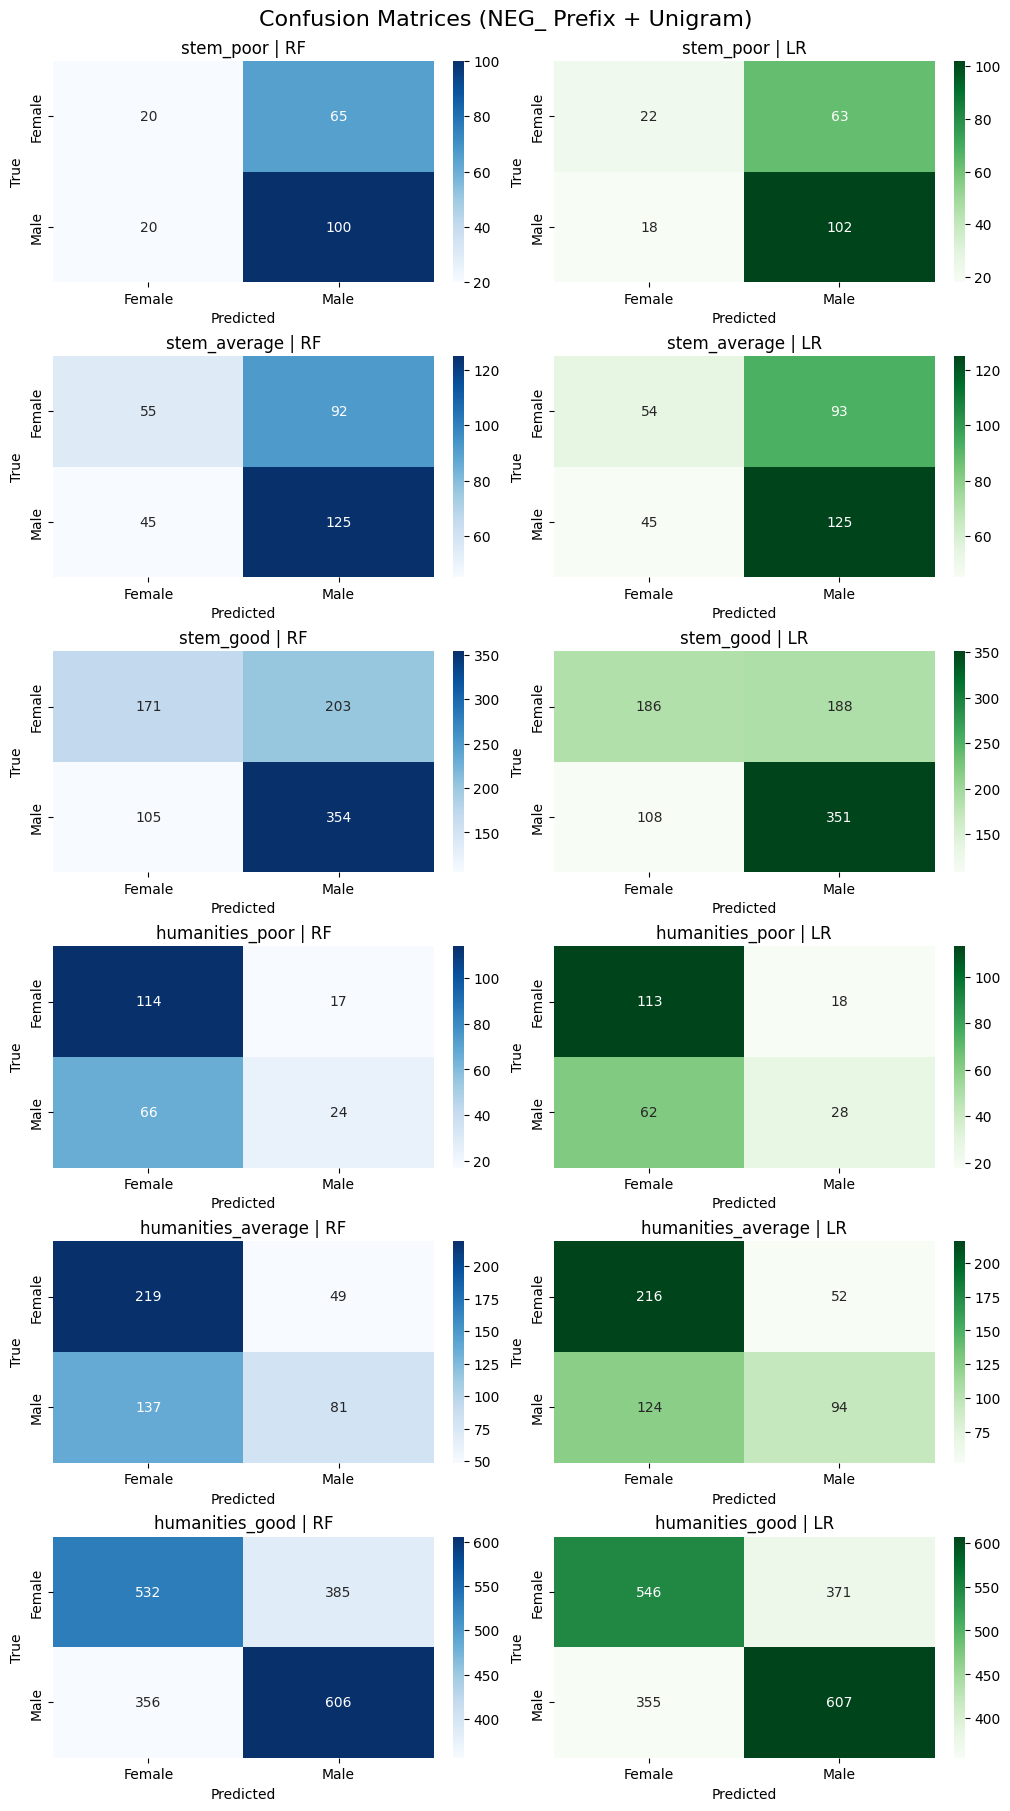

In [ ]:
FINAL_EXP = 'neg_prefixed_unigram'
LABELS = ['Female', 'Male']

fig, axes = plt.subplots(
    nrows=len(file_dict),
    ncols=2,
    figsize=(10, 3 * len(file_dict)),
    constrained_layout=True
)

for i, (dataset_label, dataset_results) in enumerate(all_results.items()):
    rf_cm = dataset_results[FINAL_EXP]['rf_metrics']['confusion_matrix']
    lr_cm = dataset_results[FINAL_EXP]['lr_metrics']['confusion_matrix']

    sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS, ax=axes[i, 0])
    axes[i, 0].set_title(f"{dataset_label} | RF")
    axes[i, 0].set_xlabel("Predicted")
    axes[i, 0].set_ylabel("True")

    sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=LABELS, yticklabels=LABELS, ax=axes[i, 1])
    axes[i, 1].set_title(f"{dataset_label} | LR")
    axes[i, 1].set_xlabel("Predicted")
    axes[i, 1].set_ylabel("True")

plt.suptitle("Confusion Matrices (NEG_ Prefix + Unigram)", fontsize=16)
plt.show()


## 3.3 Heatmap


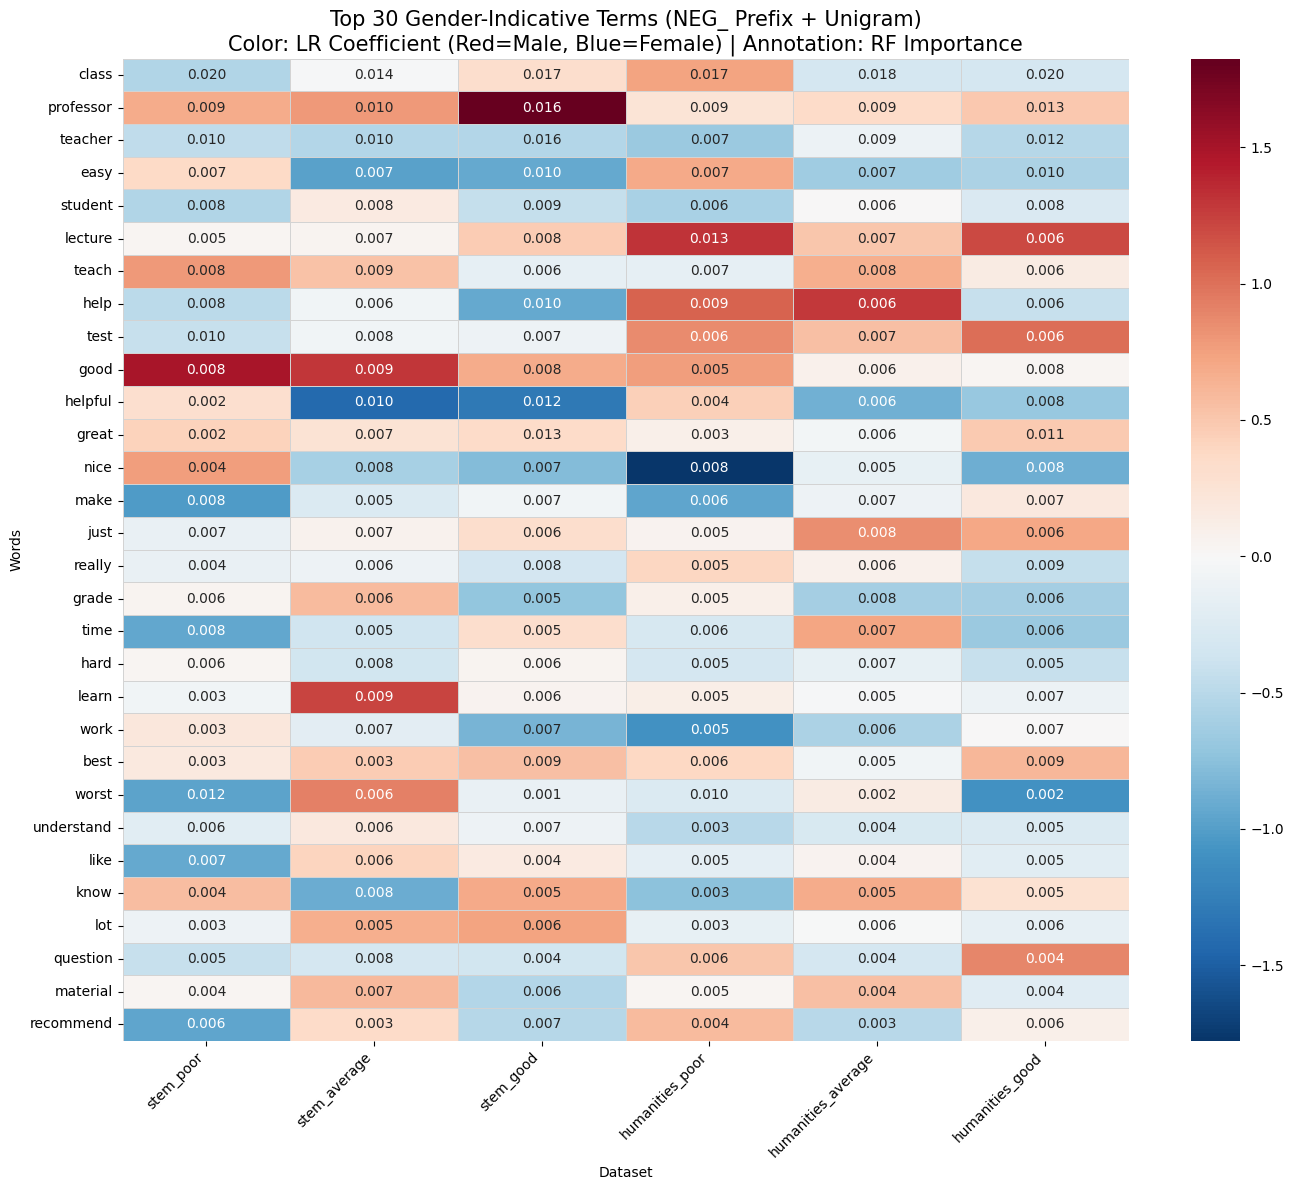

In [ ]:
FINAL_EXP = 'neg_prefixed_unigram'

heatmap_data_coeffs = {}
heatmap_data_importances = {}

for dataset_label, dataset_results in all_results.items():
    col_name = dataset_label

    # LR coefficients (directional effect)
    heatmap_data_coeffs[col_name] = (
        dataset_results[FINAL_EXP]['lr_coefficients']
        .set_index('Word')['LR_Coefficient']
    )

    # RF importance (predictive strength)
    heatmap_data_importances[col_name] = (
        dataset_results[FINAL_EXP]['rf_importance']
        .set_index('Word')['RF_Importance']
    )

heatmap_data_coeffs = pd.DataFrame(heatmap_data_coeffs).fillna(0)
heatmap_data_importances = pd.DataFrame(heatmap_data_importances).fillna(0)

# select top 30 words by overall RF importance
combined_importances = heatmap_data_importances.sum(axis=1)
top_30_words = combined_importances.nlargest(30).index

filtered_coeffs = heatmap_data_coeffs.loc[top_30_words]
filtered_importances = heatmap_data_importances.loc[top_30_words]

# plot
plt.figure(figsize=(14, 12))
sns.heatmap(
    filtered_coeffs,
    cmap='RdBu_r',
    center=0,
    annot=filtered_importances,
    fmt='.3f',
    linewidths=.5,
    linecolor='lightgray'
)

plt.title(
    "Top 30 Gender-Indicative Terms (NEG_ Prefix + Unigram)\n"
    "Color: LR Coefficient (Red=Male, Blue=Female) | "
    "Annotation: RF Importance",
    fontsize=15
)
plt.xlabel("Dataset")
plt.ylabel("Words")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.4 Top-word lists

In [ ]:
print("\n=====================================")
print("Top 20 Words (Unigram + NEG_ prefix)")
print("=====================================")

top_words_unigram = {}

for dataset_label, dataset_results in all_results.items():

    print(f"\nDataset: {dataset_label}")
    results = dataset_results['neg_prefixed_unigram']

    # RF importance
    rf_df = results['rf_importance']

    # LR coefficients
    lr_df = results['lr_coefficients']

    # merge RF + LR
    combined_df_unigram = pd.merge(
        rf_df,
        lr_df[['Word', 'LR_Coefficient', 'Direction']],
        on='Word',
        how='inner'
    )

    # rank by RF importance primarily
    combined_df_unigram = combined_df_unigram.sort_values(
        by='RF_Importance',
        ascending=False
    )

    # take top 20
    top20_unigram = combined_df_unigram.head(20)
    top_words_unigram[dataset_label] = top20_unigram

    print(f"{'Word':<20} {'Feature Importance':<20} {'Coefficient':<15} {'Direction':<10}")
    print("-"*70)

    for _, row in top20_unigram.iterrows():
        print(f"{row['Word']:<20} "
              f"{row['RF_Importance']:<20.6f} "
              f"{row['LR_Coefficient']:<15.6f} "
              f"{row['Direction']:<10}")


Top 20 Words (Unigram + NEG_ prefix)

Dataset: stem_poor
Word                 Feature Importance   Coefficient     Direction 
----------------------------------------------------------------------
class                0.019635             -0.547623       Female    
worst                0.011652             -0.968547       Female    
test                 0.009985             -0.419794       Female    
teacher              0.009581             -0.468112       Female    
professor            0.008826             0.671783        Male      
make                 0.008479             -1.025383       Female    
student              0.008387             -0.547968       Female    
teach                0.008253             0.796117        Male      
help                 0.007987             -0.496173       Female    
good                 0.007609             1.494766        Male      
avoid                0.007550             0.545721        Male      
time                 0.007515             -

## 3.4* Top-word lists (bigram)

In [ ]:
print("\n=====================================")
print("Top 20 Words (Bigram + NEG_ prefix)")
print("=====================================")

top_words_bigram = {}

for dataset_label, dataset_results in all_results.items():

    print(f"\nDataset: {dataset_label}")
    results = dataset_results['neg_prefixed_bigram']

    # RF importance
    rf_df_bigram = results['rf_importance']

    # LR coefficients
    lr_df_bigram = results['lr_coefficients']

    # merge RF + LR
    combined_df_bigram = pd.merge(
        rf_df_bigram,
        lr_df_bigram[['Word', 'LR_Coefficient', 'Direction']],
        on='Word',
        how='inner'
    )

    # sort by RF importance
    combined_df_bigram = combined_df_bigram.sort_values(
        by='RF_Importance',
        ascending=False
    )

    # take top 20
    top20_bigram = combined_df_bigram.head(20)
    top_words_bigram[dataset_label] = top20_bigram

    print(f"{'Word':<25} {'Feature Importance':<20} {'Coefficient':<15} {'Direction':<10}")
    print("-"*75)

    for _, row in top20_bigram.iterrows():
        print(f"{row['Word']:<25} "
              f"{row['RF_Importance']:<20.6f} "
              f"{row['LR_Coefficient']:<15.6f} "
              f"{row['Direction']:<10}")


Top 20 Words (Bigram + NEG_ prefix)

Dataset: stem_poor
Word                      Feature Importance   Coefficient     Direction 
---------------------------------------------------------------------------
worst teacher             0.011273             -1.131411       Female    
dr carson                 0.009160             -1.061827       Female    
easy class                0.008884             -0.555714       Female    
hard understand           0.008294             -0.347495       Female    
hard grader               0.007421             -0.841581       Female    
horrible teacher          0.006295             -0.384193       Female    
worst professor           0.006118             -0.200986       Female    
easy understand           0.006077             -0.782068       Female    
neg_class terrible        0.005616             -0.549349       Female    
student make              0.005494             -0.764203       Female    
drop class                0.005461             -0.697

# 4. Word cloud visualization

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud

In [ ]:
# color mapping (male-red, female-blue)
male_color = "#D7191C"
female_color = "#2C7BB6"

def make_color_func(direction_map):
    def color_func(word, *args, **kwargs):
        return male_color if direction_map[word] == "Male" else female_color
    return color_func

subset_labels = list(file_dict.keys())
cols = 3
rows = int(np.ceil(len(subset_labels)/cols))

## 4.1 Unigram

Unigram — RF+LR


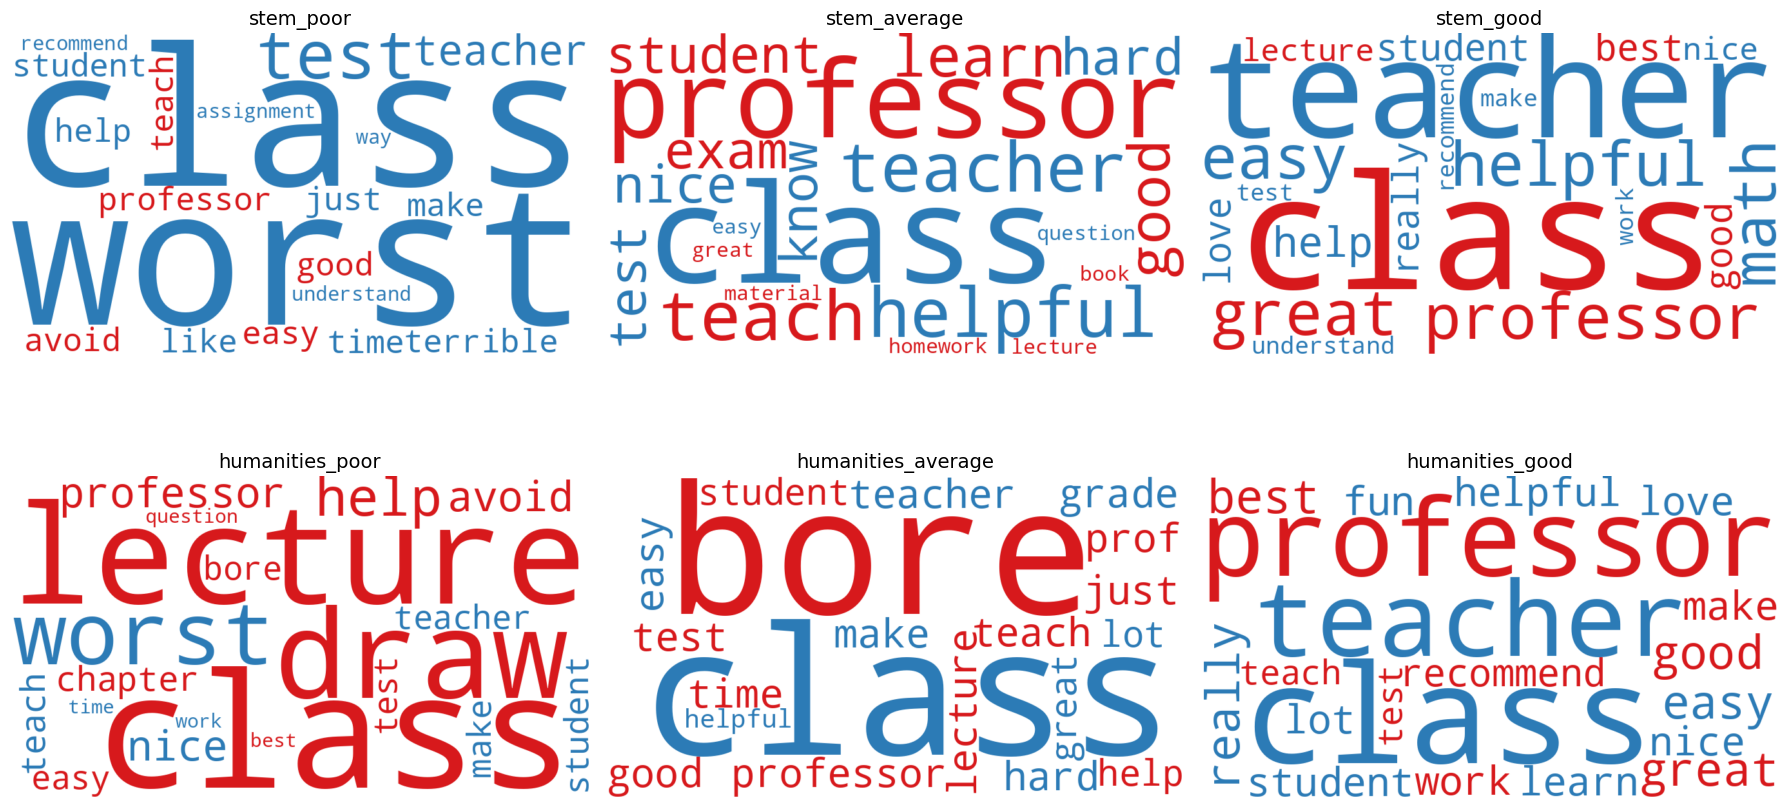

In [ ]:
print("Unigram — RF+LR")

# compute global scaling
global_max_rf_uni = 0
for label in subset_labels:
    df = top_words_unigram[label]
    global_max_rf_uni = max(global_max_rf_uni, df['RF_Importance'].max())

plt.figure(figsize=(18,10))

for i, label in enumerate(subset_labels, 1):

    df = top_words_unigram[label]

    # word size ∝ RF importance
    freq_dict = {
        row['Word']: row['RF_Importance']/global_max_rf_uni
        for _, row in df.iterrows()
    }

    direction_map = {
        row['Word']: row['Direction']
        for _, row in df.iterrows()
    }

    wc = WordCloud(
        width=900,
        height=500,
        background_color='white',
        prefer_horizontal=0.9,
        relative_scaling=0,
        min_font_size=12
    ).generate_from_frequencies(freq_dict)

    wc.recolor(color_func=make_color_func(direction_map))

    plt.subplot(rows, cols, i)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(label, fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4.2 Bigram

Bigram — RF+LR


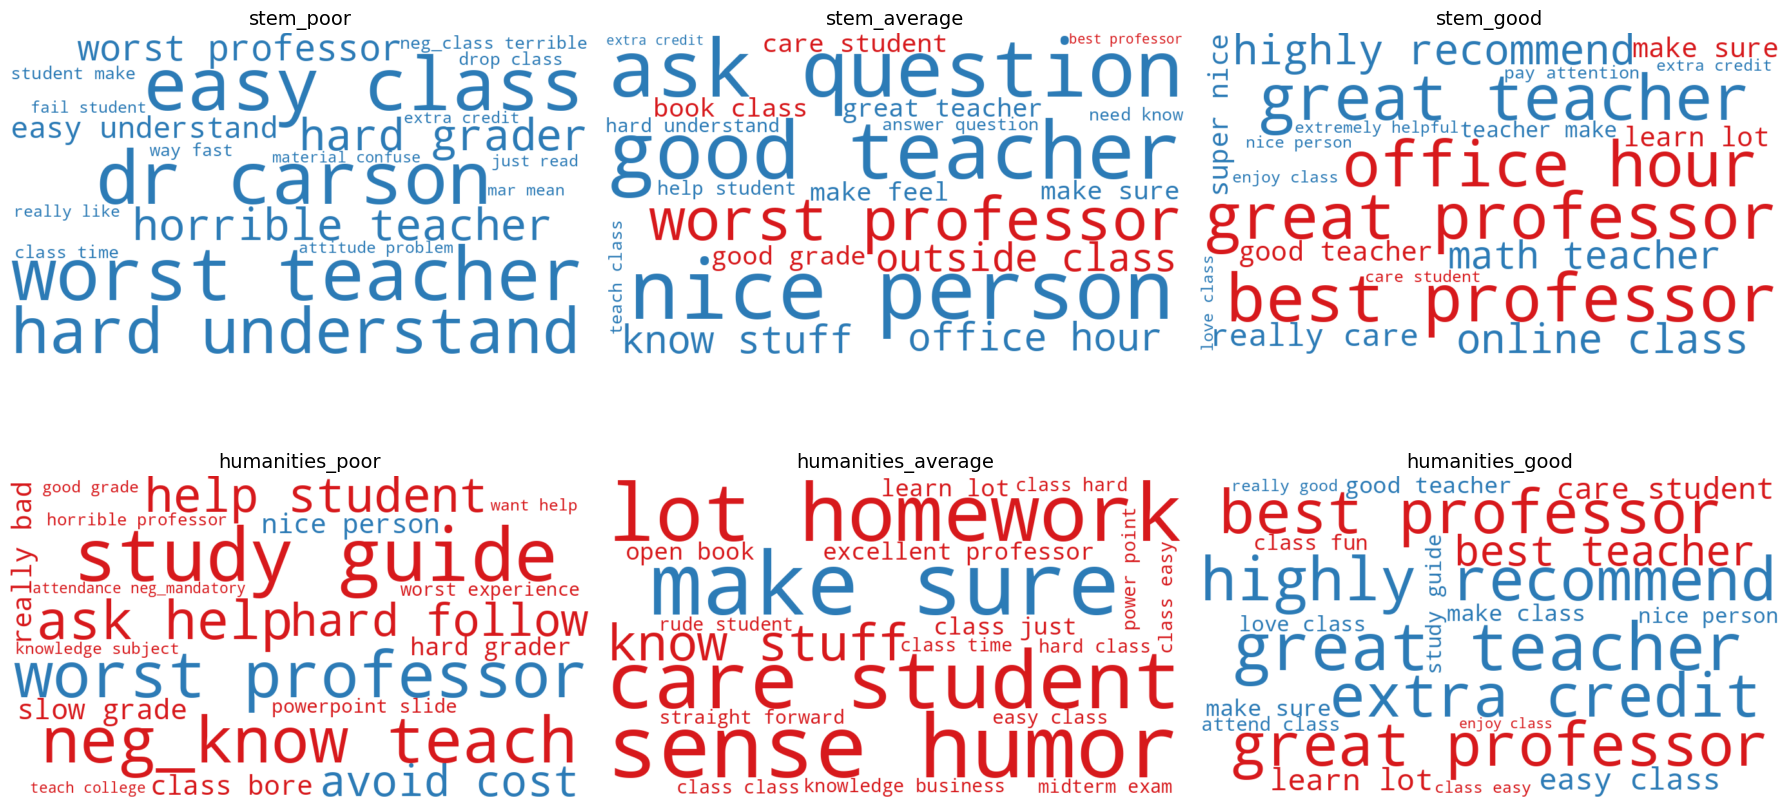

In [ ]:
print("Bigram — RF+LR")

global_max_rf_bi = 0
for label in subset_labels:
    df = top_words_bigram[label]
    global_max_rf_bi = max(global_max_rf_bi, df['RF_Importance'].max())

plt.figure(figsize=(18,10))

for i, label in enumerate(subset_labels, 1):

    df = top_words_bigram[label]

    freq_dict = {
        row['Word']: row['RF_Importance']/global_max_rf_bi
        for _, row in df.iterrows()
    }

    direction_map = {
        row['Word']: row['Direction']
        for _, row in df.iterrows()
    }

    wc = WordCloud(
        width=900,
        height=500,
        background_color='white',
        prefer_horizontal=0.9,
        relative_scaling=0,
        min_font_size=12
    ).generate_from_frequencies(freq_dict)

    wc.recolor(color_func=make_color_func(direction_map))

    plt.subplot(rows, cols, i)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(label, fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()